<a href="https://colab.research.google.com/github/DMinor279/Looker-Capstone-Project/blob/main/symptom_classification_hiv_colab_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Symptom Classification Notebook (Google Colab)

This notebook uploads the **original symptom dataset**, trains **4 classification models** to predict the **output variable**, evaluates them with **accuracy, precision, recall, F1-score, and confusion matrices**, and performs **Explainable AI (XAI)** using **SHAP**.

It also includes an **HIV-focused analysis**:
- It tries to automatically detect an **HIV indicator** in the dataset.
- If HIV-positive records can be identified, it builds a second analysis **for people who have HIV**.

## Expected dataset layout
- **Symptoms:** from **column B to column BB**
- **Rows:** data starts from **row 2**
- **Output variable:** expected to be **outside** the symptom block, usually the next column after **BB** or a clearly named target/output column.

> Supported file formats: **CSV**, **XLSX**, **XLS**


In [1]:
# Install required packages in Colab
!pip -q install shap openpyxl xlrd


In [2]:
import warnings
warnings.filterwarnings("ignore")

import io
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

SEED = 42
np.random.seed(SEED)
print("Libraries imported successfully.")


Libraries imported successfully.


In [3]:
# Upload the original symptom dataset
uploaded = files.upload()

if not uploaded:
    raise ValueError("No file uploaded. Please upload your original symptom dataset.")

file_name = list(uploaded.keys())[0]
print(f"Uploaded file: {file_name}")

ext = os.path.splitext(file_name)[1].lower()

if ext == ".csv":
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
elif ext in [".xlsx", ".xls"]:
    # Reads the first sheet by default
    df = pd.read_excel(io.BytesIO(uploaded[file_name]), sheet_name=0)
else:
    raise ValueError("Unsupported file format. Please upload a CSV, XLSX, or XLS file.")

print("Dataset shape:", df.shape)
display(df.head())


Saving Original Symptoms_data.xlsx to Original Symptoms_data.xlsx
Uploaded file: Original Symptoms_data.xlsx
Dataset shape: (3914, 54)


,REC,PHYEXP,PATAGE,PATSEX,ABDPN,BCKPN,BITAIM,BLDN,BLDYURN,CTRH,...,REDEYE,REDEYEFCTNG,SENLHT,SHK,SKNRSH,SRTRT,SPPBPN,URNFQC,VMT,WHZ
0,1,5,5,1,4,4,4,1,1,3,...,3,3,3,4,2,1,2,1,4,4
1,2,5,6,1,2,3,2,1,1,3,...,1,4,2,4,4,1,1,1,2,1
2,3,5,27,1,1,1,3,1,1,2,...,2,3,1,1,4,2,1,1,1,1
3,4,5,30,2,3,1,3,1,2,3,...,1,1,1,1,1,3,4,4,4,1
4,5,5,30,1,3,3,1,1,4,1,...,1,1,1,1,4,1,4,3,3,1


In [4]:
# Basic dataset inspection
print("Columns:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

print("\nMissing values per column (top 20):")
display(df.isna().sum().sort_values(ascending=False).head(20))


Columns:
0: REC
1: PHYEXP
2: PATAGE
3: PATSEX
4: ABDPN
5: BCKPN
6: BITAIM
7: BLDN
8: BLDYURN
9: CTRH
10: CHSIND
11: CHSPN
12: CHLNRIG
13: CLDYURN
14: CNST
15: CGHDRY
16: DRH
17: DIFBRT
18: DIZ
19: DRYCGH
20: FTG
21: FVR
22: HGPSFVR
23: HGGDFVR
24: SWRFVR
25: SUDONFVR
26: LWGDFVR
27: FOLBRT
28: BDYICH
29: GENBDYPN
30: GENRSH
31: HDACH
32: INTBLEPRF
33: JNTSWL
34: LTG
35: LMPNDSWL
36: MSCBDYPN
37: MUTUCR
38: NUS
39: NGTSWT
40: PNBHEYE
41: UPBCKPN
42: PNFLURNTN
43: PERTN
44: REDEYE
45: REDEYEFCTNG
46: SENLHT
47: SHK
48: SKNRSH
49: SRTRT
50: SPPBPN
51: URNFQC
52: VMT
53: WHZ

Missing values per column (top 20):


,0
REC,0
PHYEXP,0
PATAGE,0
PATSEX,0
ABDPN,0
BCKPN,0
BITAIM,0
BLDN,0
BLDYURN,0
CTRH,0


## Select symptom columns (B to BB) and identify the target/output column

By spreadsheet indexing:
- Column **A** = index 0
- Column **B** = index 1
- Column **BB** = index 53

So the symptom block is:
```python
df.iloc[:, 1:54]
```


In [5]:
# Symptoms are from column B to BB inclusive
symptom_start_idx = 1   # B
symptom_end_idx = 53    # BB inclusive

X = df.iloc[:, symptom_start_idx:symptom_end_idx + 1].copy()
print("Symptom matrix shape:", X.shape)

# Try to identify the output/target column automatically
candidate_names = ["output", "target", "label", "class", "diagnosis", "severity", "outcome", "result"]

target_col = None
non_symptom_cols = [c for c in df.columns if c not in X.columns]

# 1) Prefer a clearly named target column outside B:BB
for c in non_symptom_cols:
    if any(name in str(c).strip().lower() for name in candidate_names):
        target_col = c
        break

# 2) Otherwise, prefer the first column after BB
if target_col is None and df.shape[1] > symptom_end_idx + 1:
    target_col = df.columns[symptom_end_idx + 1]

# 3) Fallback to the last column in the dataset
if target_col is None:
    target_col = df.columns[-1]

y = df[target_col].copy()

print(f"Selected target/output column: {target_col}")
display(y.head())


Symptom matrix shape: (3914, 53)
Selected target/output column: WHZ


,WHZ
0,4
1,1
2,1
3,1
4,1


In [6]:
# Clean feature names for modeling and plotting
def clean_column_name(col):
    col = str(col).strip()
    col = re.sub(r"\s+", "_", col)
    col = re.sub(r"[^0-9a-zA-Z_]+", "", col)
    return col

original_feature_names = list(X.columns)
X.columns = [clean_column_name(c) for c in X.columns]

print("Number of symptom features:", len(X.columns))
print("First 10 symptom columns:", X.columns[:10].tolist())


Number of symptom features: 53
First 10 symptom columns: ['PHYEXP', 'PATAGE', 'PATSEX', 'ABDPN', 'BCKPN', 'BITAIM', 'BLDN', 'BLDYURN', 'CTRH', 'CHSIND']


In [7]:
# Prepare X and y
# Convert object features to numeric where possible; otherwise encode Yes/No style values
def normalize_binary_text(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, str):
        v = val.strip().lower()
        if v in ["yes", "y", "present", "positive", "true", "1"]:
            return 1
        if v in ["no", "n", "absent", "negative", "false", "0"]:
            return 0
    return val

X = X.applymap(normalize_binary_text)
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Target cleanup
y = y.astype(str).str.strip()
valid_mask = y.notna() & (y != "") & (y.str.lower() != "nan")

X = X.loc[valid_mask].reset_index(drop=True)
y = y.loc[valid_mask].reset_index(drop=True)

print("Usable dataset shape after cleanup:", X.shape, y.shape)
print("Target distribution:")
display(y.value_counts(dropna=False))


Usable dataset shape after cleanup: (3914, 53) (3914,)
Target distribution:


,count
WHZ,
1,3630
2,141
3,96
4,35
5,12


In [8]:
# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:")
for idx, cls in enumerate(label_encoder.classes_):
    print(f"{idx}: {cls}")


Encoded classes:
0: 1
1: 2
2: 3
3: 4
4: 5


In [9]:
# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded if len(np.unique(y_encoded)) > 1 else None
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (3131, 53) (3131,)
Test shape: (783, 53) (783,)


In [10]:
# Build the four classification models
models = {
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("model", DecisionTreeClassifier(random_state=SEED, max_depth=None))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=SEED,
            class_weight="balanced_subsample"
        ))
    ]),

    "Support Vector Machine": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=SEED))
    ]),

    "Artificial Neural Network": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            max_iter=500,
            random_state=SEED
        ))
    ])
}

print("Models ready:", list(models.keys()))


Models ready: ['Decision Tree', 'Random Forest', 'Support Vector Machine', 'Artificial Neural Network']



Training: Decision Tree
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       726
           2       1.00      1.00      1.00        28
           3       1.00      1.00      1.00        19
           4       1.00      1.00      1.00         7
           5       1.00      1.00      1.00         3

    accuracy                           1.00       783
   macro avg       1.00      1.00      1.00       783
weighted avg       1.00      1.00      1.00       783



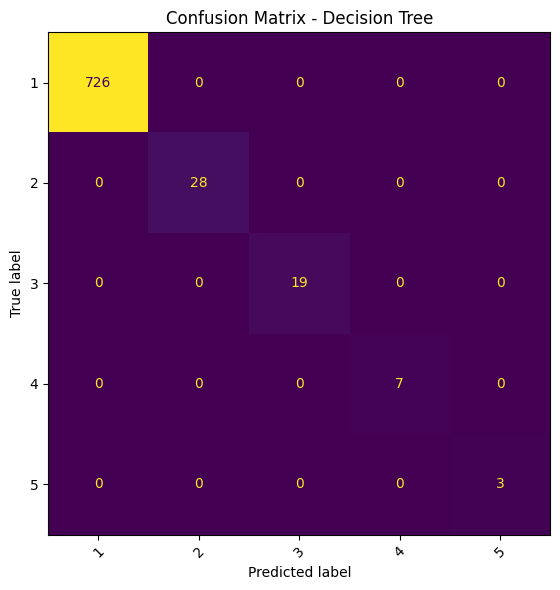


Training: Random Forest
              precision    recall  f1-score   support

           1       0.98      1.00      0.99       726
           2       0.94      0.61      0.74        28
           3       0.87      0.68      0.76        19
           4       1.00      0.43      0.60         7
           5       1.00      1.00      1.00         3

    accuracy                           0.97       783
   macro avg       0.96      0.74      0.82       783
weighted avg       0.97      0.97      0.97       783



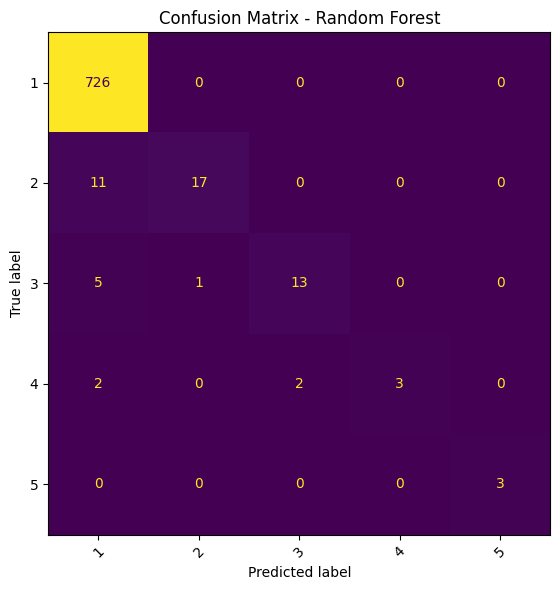


Training: Support Vector Machine
              precision    recall  f1-score   support

           1       0.97      1.00      0.99       726
           2       0.82      0.50      0.62        28
           3       0.80      0.63      0.71        19
           4       1.00      0.43      0.60         7
           5       1.00      0.33      0.50         3

    accuracy                           0.97       783
   macro avg       0.92      0.58      0.68       783
weighted avg       0.96      0.97      0.96       783



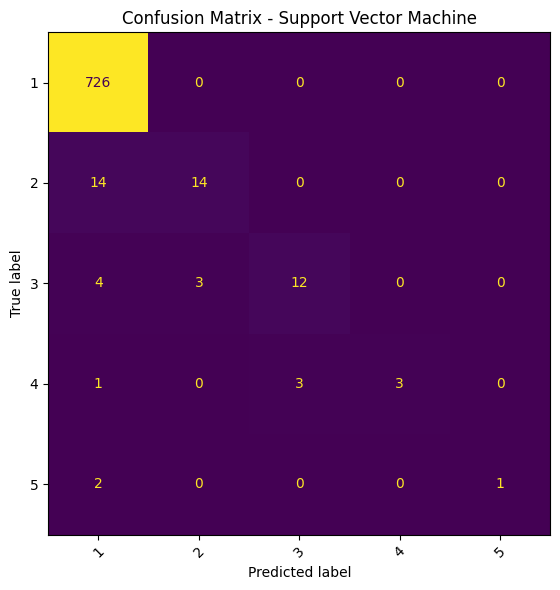


Training: Artificial Neural Network
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       726
           2       0.83      0.86      0.84        28
           3       0.74      0.74      0.74        19
           4       0.75      0.43      0.55         7
           5       0.50      0.33      0.40         3

    accuracy                           0.98       783
   macro avg       0.76      0.67      0.70       783
weighted avg       0.98      0.98      0.98       783



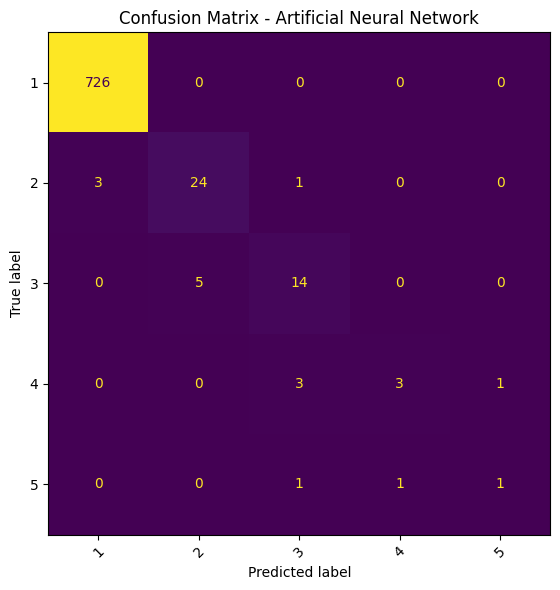


Model performance summary:


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,1.000000,1.000000,1.000000,1.000000
1,Artificial Neural Network,0.980843,0.979482,0.980843,0.979694
2,Random Forest,0.973180,0.972346,0.973180,0.970032
3,Support Vector Machine,0.965517,0.962770,0.965517,0.960643


In [11]:
# Train, evaluate, and plot confusion matrices
results = []
trained_models = {}

for name, model in models.items():
    print(f"\n{'='*70}\nTraining: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    trained_models[name] = model

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

    print(classification_report(
        y_test, y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
print("\nModel performance summary:")
display(results_df)


In [12]:
# Select the best model by F1 Score
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

print(f"Best model selected for XAI: {best_model_name}")


Best model selected for XAI: Decision Tree


## HIV-focused output analysis

This section tries to identify **people who have HIV** in one of these ways:
1. A column name contains **HIV**
2. A dataset value contains **HIV**
3. A binary HIV-related column exists and can be converted to 0/1

If HIV-positive records are found, the notebook creates a subset and repeats the classification workflow **within the HIV-positive group**.


In [13]:
# Detect HIV-related records
def detect_hiv_subset(df_original):
    hiv_cols = [c for c in df_original.columns if "hiv" in str(c).lower()]
    hiv_mask = pd.Series(False, index=df_original.index)

    # Case 1: HIV-related columns
    for c in hiv_cols:
        series = df_original[c]
        if pd.api.types.is_numeric_dtype(series):
            hiv_mask = hiv_mask | (series.fillna(0).astype(float) > 0)
        else:
            s = series.astype(str).str.strip().str.lower()
            hiv_mask = hiv_mask | s.isin(["yes", "y", "positive", "present", "true", "1", "hiv"])
            hiv_mask = hiv_mask | s.str.contains("hiv", na=False)

    # Case 2: Values in target column mention HIV
    if target_col in df_original.columns:
        target_text = df_original[target_col].astype(str).str.lower()
        hiv_mask = hiv_mask | target_text.str.contains("hiv", na=False)

    return hiv_cols, hiv_mask

hiv_cols, hiv_mask = detect_hiv_subset(df)

print("HIV-related columns detected:", hiv_cols)
print("Number of HIV-positive rows detected:", int(hiv_mask.sum()))


HIV-related columns detected: []
Number of HIV-positive rows detected: 0


In [14]:
# Optional HIV-positive cohort modeling
hiv_results_df = None
hiv_models = {}

if hiv_mask.sum() >= 20:
    df_hiv = df.loc[hiv_mask].copy().reset_index(drop=True)
    X_hiv = df_hiv.iloc[:, symptom_start_idx:symptom_end_idx + 1].copy()
    X_hiv.columns = [clean_column_name(c) for c in X_hiv.columns]
    X_hiv = X_hiv.applymap(normalize_binary_text)
    for col in X_hiv.columns:
        X_hiv[col] = pd.to_numeric(X_hiv[col], errors="coerce")

    y_hiv = df_hiv[target_col].astype(str).str.strip()
    valid_hiv = y_hiv.notna() & (y_hiv != "") & (y_hiv.str.lower() != "nan")
    X_hiv = X_hiv.loc[valid_hiv].reset_index(drop=True)
    y_hiv = y_hiv.loc[valid_hiv].reset_index(drop=True)

    if y_hiv.nunique() >= 2:
        le_hiv = LabelEncoder()
        y_hiv_encoded = le_hiv.fit_transform(y_hiv)

        Xh_train, Xh_test, yh_train, yh_test = train_test_split(
            X_hiv, y_hiv_encoded,
            test_size=0.20,
            random_state=SEED,
            stratify=y_hiv_encoded if len(np.unique(y_hiv_encoded)) > 1 else None
        )

        hiv_results = []

        for name, model in models.items():
            print(f"\nTraining HIV cohort model: {name}")
            model.fit(Xh_train, yh_train)
            yh_pred = model.predict(Xh_test)
            hiv_models[name] = model

            hiv_results.append({
                "Model": name,
                "Accuracy": accuracy_score(yh_test, yh_pred),
                "Precision": precision_score(yh_test, yh_pred, average="weighted", zero_division=0),
                "Recall": recall_score(yh_test, yh_pred, average="weighted", zero_division=0),
                "F1 Score": f1_score(yh_test, yh_pred, average="weighted", zero_division=0)
            })

            cm = confusion_matrix(yh_test, yh_pred)
            fig, ax = plt.subplots(figsize=(8, 6))
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_hiv.classes_)
            disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
            plt.title(f"HIV Cohort Confusion Matrix - {name}")
            plt.tight_layout()
            plt.show()

        hiv_results_df = pd.DataFrame(hiv_results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
        print("HIV cohort performance summary:")
        display(hiv_results_df)
    else:
        print("HIV-positive subset found, but it does not contain at least 2 output classes.")
else:
    print("Not enough HIV-positive rows were detected for a reliable HIV-focused model.")


Not enough HIV-positive rows were detected for a reliable HIV-focused model.


## Explainable AI with SHAP

To keep the analysis stable and efficient, the notebook explains the **best model** when possible.  
For tree-based models, SHAP works very well. If the best model is not tree-based, the notebook still fits a **Random Forest explainer model** as a practical XAI fallback.

Two plots are generated:
- **SHAP summary plot**
- **Feature importance bar plot**


In [15]:
# Prepare data for SHAP
X_train_imp = pd.DataFrame(
    SimpleImputer(strategy="most_frequent").fit_transform(X_train),
    columns=X_train.columns
)

X_test_imp = pd.DataFrame(
    SimpleImputer(strategy="most_frequent").fit(X_train).transform(X_test),
    columns=X_test.columns
)

# Choose a model for SHAP
if best_model_name in ["Decision Tree", "Random Forest"]:
    shap_model = best_model.named_steps["model"]
    shap_model_name = best_model_name
else:
    # Fallback: explain a random forest model trained on the same data
    shap_fallback = RandomForestClassifier(
        n_estimators=200,
        random_state=SEED,
        class_weight="balanced_subsample"
    )
    shap_fallback.fit(X_train_imp, y_train)
    shap_model = shap_fallback
    shap_model_name = "Random Forest (XAI fallback)"

print(f"Using {shap_model_name} for SHAP explanation.")


Using Decision Tree for SHAP explanation.


Generating SHAP summary plot...


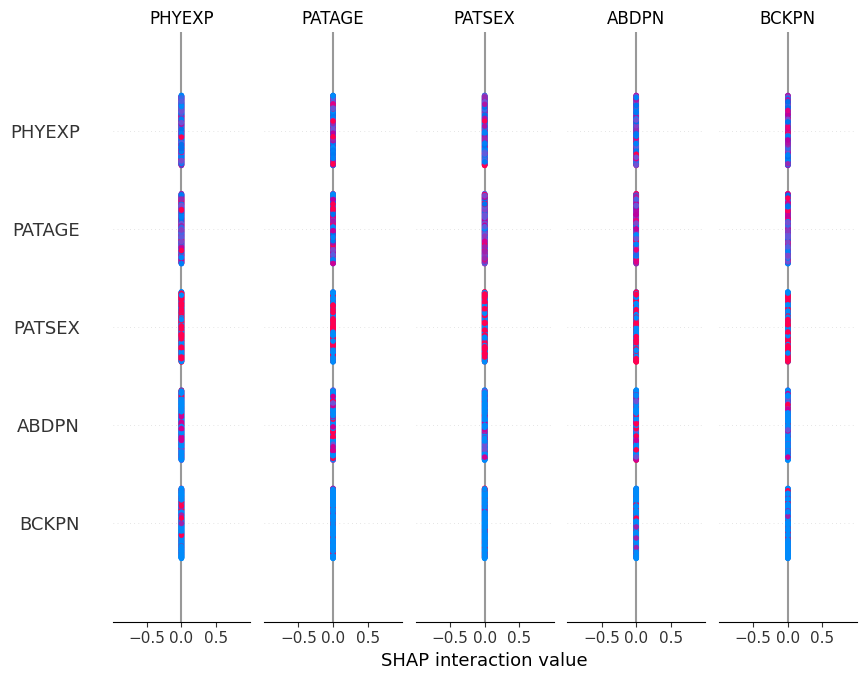

Generating SHAP bar plot...


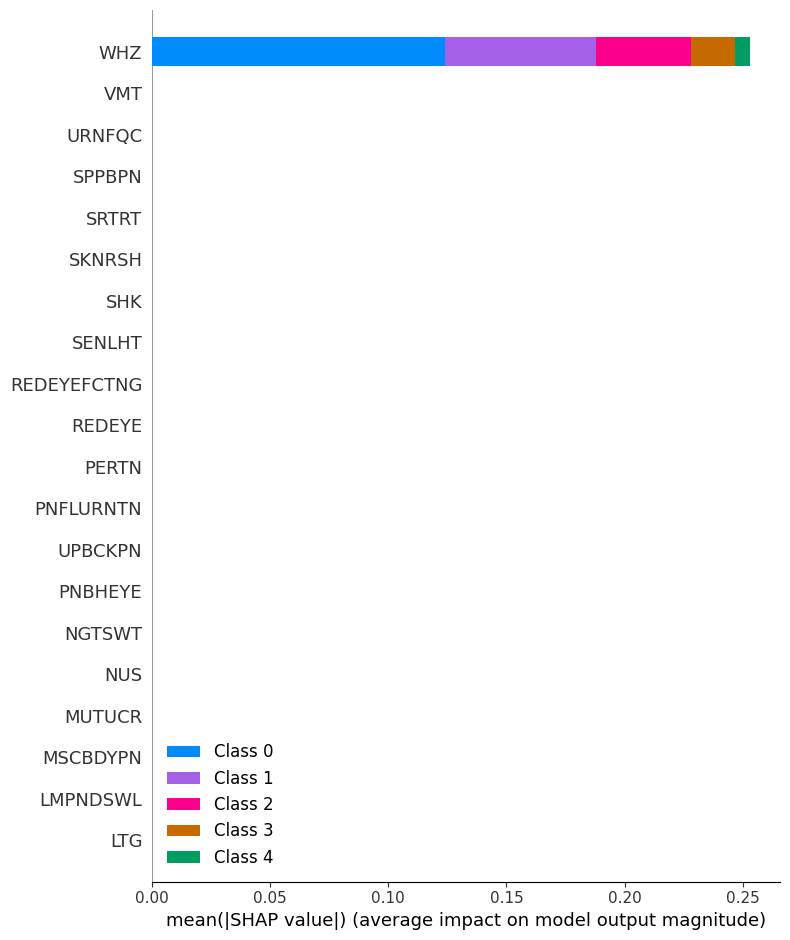

In [16]:
# SHAP analysis
sample_size = min(300, len(X_test_imp))
X_shap = X_test_imp.sample(sample_size, random_state=SEED) if len(X_test_imp) > sample_size else X_test_imp.copy()

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)

print("Generating SHAP summary plot...")
shap.summary_plot(shap_values, X_shap, feature_names=X_shap.columns, show=True)

print("Generating SHAP bar plot...")
shap.summary_plot(shap_values, X_shap, feature_names=X_shap.columns, plot_type="bar", show=True)


In [17]:
# Save model performance tables
results_df.to_csv("overall_model_performance.csv", index=False)
print("Saved overall_model_performance.csv")

if hiv_results_df is not None:
    hiv_results_df.to_csv("hiv_cohort_model_performance.csv", index=False)
    print("Saved hiv_cohort_model_performance.csv")


Saved overall_model_performance.csv


## Notes
- The notebook assumes the **symptoms are in columns B to BB**.
- The notebook **automatically detects the target/output column**, but you can manually change `target_col` if needed.
- If the dataset contains a clear **HIV indicator**, the notebook performs an **HIV-specific classification analysis**.
- SHAP explanations are generated for the **best model** when possible, or a **Random Forest fallback** for interpretability.

You can now run this notebook in **Google Colab** by uploading it and then uploading your original dataset when prompted.
